# Spam Dataset Analysis

This notebook loads and explores the spam dataset to understand its structure and characteristics.

## Section 1: Import Required Libraries

Import the necessary libraries, including Pandas and NumPy.

In [44]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

## Section 2: Load the Dataset into a Pandas DataFrame

Load data from the spam.csv file into a Pandas DataFrame using read_csv() function.

In [70]:
import os
# Load the new dataset (WELFake_Dataset.csv)
dataset_path = 'WELFake_Dataset.csv'
if not os.path.exists(dataset_path):
    raise FileNotFoundError(f"{dataset_path} not found in the notebook working directory")
try:
    df = pd.read_csv(dataset_path, encoding='utf-8', low_memory=False)
except Exception:
    df = pd.read_csv(dataset_path, encoding='latin-1', low_memory=False)

print(f"Dataset loaded successfully: {dataset_path}")
print(f"Shape: {df.shape}")


Dataset loaded successfully: WELFake_Dataset.csv
Shape: (72134, 4)


In [71]:
# Preview the raw CSV to inspect headers and sample rows
try:
    df_raw = pd.read_csv(dataset_path, nrows=5, encoding='utf-8', low_memory=False)
except Exception:
    df_raw = pd.read_csv(dataset_path, nrows=5, encoding='latin-1', low_memory=False)

print('Columns:', df_raw.columns.tolist())
print('\nSample rows:')
print(df_raw.head().to_string())


Columns: ['Unnamed: 0', 'title', 'text', 'label']

Sample rows:
   Unnamed: 0                                                                                                                                      title                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                

In [72]:
# Print just the column names and dtypes for clarity
print('Columns:', df_raw.columns.tolist())
print('\nDtypes:')
print(df_raw.dtypes.to_dict())


Columns: ['Unnamed: 0', 'title', 'text', 'label']

Dtypes:
{'Unnamed: 0': dtype('int64'), 'title': dtype('O'), 'text': dtype('O'), 'label': dtype('int64')}


In [73]:
# Show title and label for first 10 raw rows to inspect label semantics
print(df_raw[['title', 'label']].head(10).to_string())
print('\nSample label unique values (first 10):')
print(df_raw['label'].unique()[:10])


                                                                                                                                       title  label
0         LAW ENFORCEMENT ON HIGH ALERT Following Threats Against Cops And Whites On 9-11By #BlackLivesMatter And #FYF911 Terrorists [VIDEO]      1
1                                                                                                                                        NaN      1
2  UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MOST CHARLOTTE RIOTERS WERE “PEACEFUL” PROTESTERS…In Her Home State Of North Carolina [VIDEO]      1
3                                  Bobby Jindal, raised Hindu, uses story of Christian conversion to woo evangelicals for potential 2016 bid      0
4                                            SATAN 2: Russia unvelis an image of its terrifying new ‘SUPERNUKE’ – Western world takes notice      1

Sample label unique values (first 10):
[1 0]


In [74]:
# Select appropriate columns for label and message
if 'label' in df.columns and 'text' in df.columns:
    df = df[['label', 'text']].copy()
    df.columns = ['label', 'message']
else:
    df = df.iloc[:, [0, 1]].copy()
    df.columns = ['label', 'message']

# If label is numeric but actually represents categories, attempt mapping (common for WELFake)
if df['label'].dtype != 'object':
    # If labels are integers like 0/1 or 0..N, leave as-is; otherwise try to coerce
    pass

# Show a brief confirmation
print('Selected columns and renamed to `label` and `message`.')
print(df.head())


Selected columns and renamed to `label` and `message`.
   label                                            message
0      1  No comment is expected from Barack Obama Membe...
1      1     Did they post their votes for Hillary already?
2      1   Now, most of the demonstrators gathered last ...
3      0  A dozen politically active pastors came here f...
4      1  The RS-28 Sarmat missile, dubbed Satan 2, will...


In [75]:
print(f"Dataset Shape: {df.shape}")

Dataset Shape: (72134, 2)


In [76]:
print(df.head())

   label                                            message
0      1  No comment is expected from Barack Obama Membe...
1      1     Did they post their votes for Hillary already?
2      1   Now, most of the demonstrators gathered last ...
3      0  A dozen politically active pastors came here f...
4      1  The RS-28 Sarmat missile, dubbed Satan 2, will...


In [77]:
counts = df['label'].value_counts()
print(counts)

label
1    37106
0    35028
Name: count, dtype: int64


In [63]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
label       0
message    39
dtype: int64


In [64]:
percentage = df['label'].value_counts(normalize=True) * 100
print("Percentage Distribution:")
print(percentage)

Percentage Distribution:
label
1    51.440375
0    48.559625
Name: proportion, dtype: float64


In [66]:
# Create message length column (handle missing values)
df['msg_length'] = df['message'].fillna('').apply(len)


In [67]:
stats = df.groupby('label')['msg_length'].agg(['mean', 'min', 'max'])
print("Message Length Statistics (Ham vs Spam):")
print(stats)

Message Length Statistics (Ham vs Spam):
              mean  min     max
label                          
0      3495.316690    1   85948
1      3054.167385    0  142961


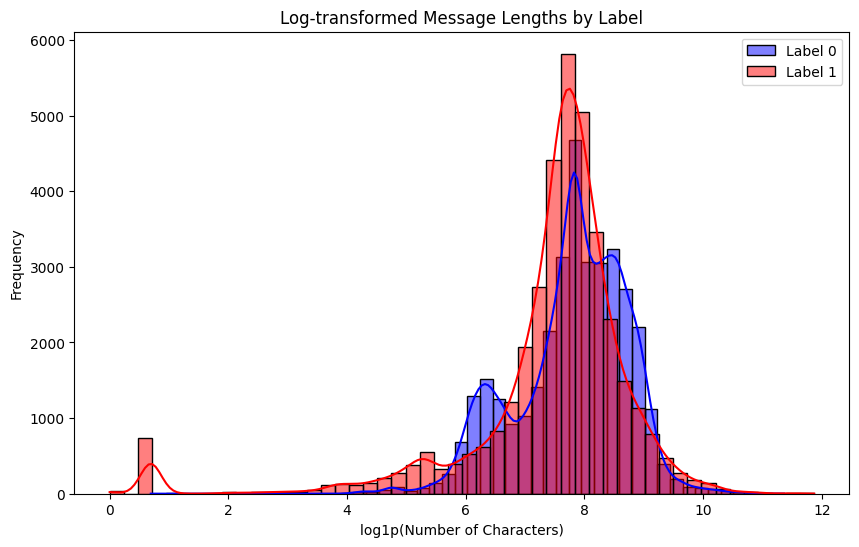

In [69]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(10, 6))

# Plotting log-transformed message lengths
sns.histplot(np.log1p(df[df['label'] == 0]['msg_length']), 
             color='blue', label='Label 0', kde=True, bins=50)

sns.histplot(np.log1p(df[df['label'] == 1]['msg_length']), 
             color='red', label='Label 1', kde=True, bins=50)

plt.title('Log-transformed Message Lengths by Label')
plt.xlabel('log1p(Number of Characters)')
plt.ylabel('Frequency')
plt.legend()
plt.show()


TASK 3: Data Cleaning and Preprocessing

In [26]:
import nltk
import string
import re
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

# Download necessary NLTK data
nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ALH\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ALH\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [83]:
# Initialize the Stemmer and Stopwords list
stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    # 1. Convert to lowercase
    text = text.lower()
    
    # 2. Remove numbers and punctuation using Regex
    # This keeps only alphabetic characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    # 3. Tokenize (Split into words)
    words = nltk.word_tokenize(text)
    
    # 4 & 5. Remove stop words and Apply Stemming
    cleaned_words = [stemmer.stem(word) for word in words if word not in stop_words]
    
    # 6. Join back into a string and return
    return " ".join(cleaned_words)

# Apply the function to create the clean_message column
df['clean_message'] = df['message'].fillna('').apply(preprocess_text)

In [80]:
# Confirm the label column is ready for modeling
df['label'] = pd.to_numeric(df['label'], errors='coerce')
print(df['label'].value_counts(dropna=False))

label
1    37106
0    35028
Name: count, dtype: int64


In [82]:
# Displaying specific columns to verify
print(df[['message', 'label']].head())

                                             message  label
0  No comment is expected from Barack Obama Membe...      1
1     Did they post their votes for Hillary already?      1
2   Now, most of the demonstrators gathered last ...      1
3  A dozen politically active pastors came here f...      0
4  The RS-28 Sarmat missile, dubbed Satan 2, will...      1


TASK 4: Feature Engineering and Selection


In [84]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# Prepare the data
X = df['clean_message']
y = df['label']

# 1. Split the dataset (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [85]:
# 2. Initialize and Fit CountVectorizer
cv = CountVectorizer(max_features=3000)
X_train_cv = cv.fit_transform(X_train)

# 3. Transform the test set
X_test_cv = cv.transform(X_test)

# 4. Print results
print("--- CountVectorizer Results ---")
print(f"Vocabulary Size: {len(cv.vocabulary_)}")
print(f"Training Matrix Shape: {X_train_cv.shape}")

--- CountVectorizer Results ---
Vocabulary Size: 3000
Training Matrix Shape: (57707, 3000)


In [86]:
# 1. Initialize and Fit TfidfVectorizer
tfidf = TfidfVectorizer(max_features=3000)
X_train_tfidf = tfidf.fit_transform(X_train)

# 2. Transform the test set
X_test_tfidf = tfidf.transform(X_test)

# 3. Print results
print("\n--- TF-IDF Results ---")
print(f"Training Matrix Shape: {X_train_tfidf.shape}")


--- TF-IDF Results ---
Training Matrix Shape: (57707, 3000)


1. What does a Bag-of-Words (BoW) vector represent?
For a single message, a BoW vector represents a frequency map. Imagine a long list of 3,000 unique words (the vocabulary). For one specific message, the vector is a list of 3,000 numbers where each number tells you how many times that specific word from the vocabulary appeared in that message. Most numbers will be 0 (since one text only uses a few words), but words like "free" or "claim" might show up as 1 or 2.

2. Difference and Use Case:

The Difference: CountVectorizer only cares about frequency (how often a word appears). TF-IDF cares about importance. It calculates a weight that increases with frequency within a single message but decreases if the word is common across the entire dataset.

When to use TF-IDF: It is more useful when your dataset contains "noise" words that aren't technically "stop words" but appear so often they don't help distinguish classes. In spam detection, if the word "phone" appears in almost every message (both ham and spam), CountVectorizer would give it a high value, but TF-IDF would lower its importance, allowing more specific "spammy" words to stand out.

TASK 5: Model Building

In [87]:
from sklearn.naive_bayes import MultinomialNB

# 1. Create the model with alpha=1.0
nb_model = MultinomialNB(alpha=1.0)

# 2. Fit the model on the CountVectorizer training data
nb_model.fit(X_train_cv, y_train)

print("Model training complete.")

Model training complete.


In [90]:
# 1. Predict labels for the test set
y_pred = nb_model.predict(X_test_cv)

# 2. Display first 10 predicted vs actual labels
import pandas as pd
results_comparison = pd.DataFrame({'Actual': y_test[:10].values, 'Predicted': y_pred[:10]})
print('\nFirst 10 Comparisons (0=Class 0, 1=Class 1):')
print(results_comparison)


First 10 Comparisons (0=Class 0, 1=Class 1):
   Actual  Predicted
0       1          1
1       1          1
2       0          0
3       0          0
4       1          1
5       1          1
6       1          1
7       0          0
8       0          0
9       1          1


TASK 6: Model Evaluation and Validation

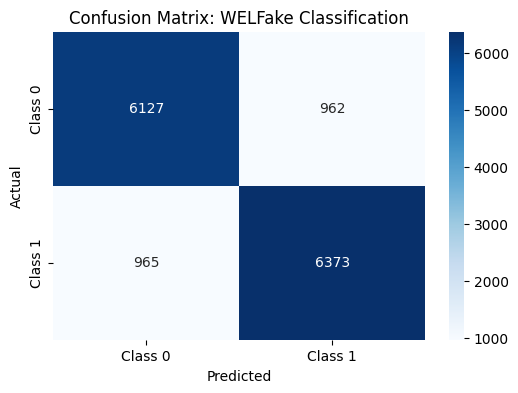

TN: 6127, FP: 962, FN: 965, TP: 6373


In [93]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Generate Matrix
cm = confusion_matrix(y_test, y_pred)

# 2. Plot Heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix: WELFake Classification')
plt.show()

# 3. Identify Values
tn, fp, fn, tp = cm.ravel()
print(f"TN: {tn}, FP: {fp}, FN: {fn}, TP: {tp}")

In [37]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Step 2: Accuracy
# Formula: (TP + TN) / (TP + TN + FP + FN)
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}")

Accuracy: 0.9794


In [38]:
# Step 3: Precision
# Formula: TP / (TP + FP)
prec = precision_score(y_test, y_pred)
print(f"Precision: {prec:.4f}")

Precision: 0.9379


In [ ]:
# Step 4: Recall
# Formula: TP / (TP + FN)
rec = recall_score(y_test, y_pred)
print(f"Recall: {rec:.4f}")

Recall: 0.9067


In [40]:
# Step 5: F1-Score
# Formula: 2 * (Precision * Recall) / (Precision + Recall)
f1 = f1_score(y_test, y_pred)
print(f"F1-Score: {f1:.4f}")

F1-Score: 0.9220


In [92]:
from sklearn.metrics import classification_report, confusion_matrix

# 1. Print Full Report
print("--- Classification Report (CountVectorizer) ---")
print(classification_report(y_test, y_pred))

# 2. Get TP, TN, FP, FN for your table
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

print(f"True Positives (TP): {tp}")
print(f"True Negatives (TN): {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")

--- Classification Report (CountVectorizer) ---
              precision    recall  f1-score   support

           0       0.86      0.86      0.86      7089
           1       0.87      0.87      0.87      7338

    accuracy                           0.87     14427
   macro avg       0.87      0.87      0.87     14427
weighted avg       0.87      0.87      0.87     14427

True Positives (TP): 6373
True Negatives (TN): 6127
False Positives (FP): 962
False Negatives (FN): 965


In [91]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 1. Train TF-IDF Model
nb_tfidf_model = MultinomialNB(alpha=1.0)
nb_tfidf_model.fit(X_train_tfidf, y_train)
y_pred_tfidf = nb_tfidf_model.predict(X_test_tfidf)

# 2. Calculate Metrics for Comparison
# Metrics for CountVectorizer (already calculated previously)
acc_cv = accuracy_score(y_test, y_pred)
prec_cv = precision_score(y_test, y_pred)
rec_cv = recall_score(y_test, y_pred)
f1_cv = f1_score(y_test, y_pred)

# Metrics for TF-IDF
acc_tf = accuracy_score(y_test, y_pred_tfidf)
prec_tf = precision_score(y_test, y_pred_tfidf)
rec_tf = recall_score(y_test, y_pred_tfidf)
f1_tf = f1_score(y_test, y_pred_tfidf)

# 3. Print Comparison Table Results
print("--- Comparison Table Values ---")
print(f"{'Metric':<15} | {'CountVectorizer':<15} | {'TF-IDF':<15}")
print("-" * 50)
print(f"{'Accuracy':<15} | {acc_cv:<15.4f} | {acc_tf:<15.4f}")
print(f"{'Precision':<15} | {prec_cv:<15.4f} | {prec_tf:<15.4f}")
print(f"{'Recall':<15} | {rec_cv:<15.4f} | {rec_tf:<15.4f}")
print(f"{'F1-Score':<15} | {f1_cv:<15.4f} | {f1_tf:<15.4f}")

--- Comparison Table Values ---
Metric          | CountVectorizer | TF-IDF         
--------------------------------------------------
Accuracy        | 0.8664          | 0.8415         
Precision       | 0.8688          | 0.8266         
Recall          | 0.8685          | 0.8711         
F1-Score        | 0.8687          | 0.8483         


Observation: You can compare CountVectorizer and TF-IDF on the WELFake labels to see which representation works better for this dataset.

Why? In text datasets like this, Bag-of-Words and TF-IDF can behave differently depending on how informative common terms are across the corpus.